In [1]:
#2.Graph KNN(k=3,5,9) compare with different k values

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# -----------------------------
# Minimal setup for Graph-KNN
# -----------------------------
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")

# train / validation / test split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)

# raw copies for KNN graph construction
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

# scaled copies for ANN
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train_raw.index
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X.columns,
    index=X_val_raw.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test_raw.index
)

print("Setup complete.")
print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("X_test_raw:", X_test_raw.shape)

Setup complete.
X_train_raw: (14860, 8)
X_val_raw: (1652, 8)
X_test_raw: (4128, 8)


n Graph-KNN with k = 3 
k = 3, Validation MSE = 0.2341, Test MSE = 0.1885
n Graph-KNN with k = 5 
k = 5, Validation MSE = 0.2248, Test MSE = 0.1877
n Graph-KNN with k = 10 
k = 10, Validation MSE = 0.2090, Test MSE = 0.1805

=== Graph-KNN Results ===
    k  Validation_MSE  Test_MSE
0   3        0.234120  0.188533
1   5        0.224767  0.187694
2  10        0.209031  0.180549


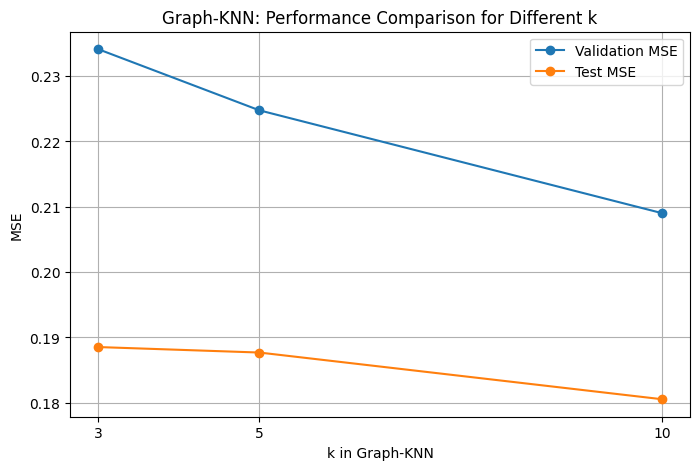

In [3]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
import pandas as pd
import matplotlib.pyplot as plt

# We use raw latitude and longitude for KNN graph construction
geo_cols = ['Latitude', 'Longitude']

# Candidate k values
k_values = [3, 5, 10]

knn_results = []

for k in k_values:
    print(f"n Graph-KNN with k = {k} ")
    
    # --------------------------------------------------------
    # Step 1: Fit KNN on TRAIN RAW coordinates only
    # --------------------------------------------------------
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_raw[geo_cols])

    # --------------------------------------------------------
    # Step 2: Build neighbour-price feature for TRAIN
    # IMPORTANT:
    # For training set, querying the same training points will
    # include itself as nearest neighbour (distance = 0).
    # So we fit another KNN with k+1 neighbours and drop self.
    # --------------------------------------------------------
    knn_train = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    knn_train.fit(X_train_raw[geo_cols])

    train_dist, train_idx = knn_train.kneighbors(X_train_raw[geo_cols])

    # exclude self (first column usually itself)
    train_idx = train_idx[:, 1:]

    # Use y_train values aligned by position
    y_train_array = y_train.to_numpy()

    train_neighbour_price = y_train_array[train_idx].mean(axis=1)

    # --------------------------------------------------------
    # Step 3: Build neighbour-price feature for VALIDATION
    # Validation points look for nearest neighbours in TRAIN only
    # --------------------------------------------------------
    val_dist, val_idx = knn.kneighbors(X_val_raw[geo_cols])
    val_neighbour_price = y_train_array[val_idx].mean(axis=1)

    # --------------------------------------------------------
    # Step 4: Build neighbour-price feature for TEST
    # Test points also look for nearest neighbours in TRAIN only
    # --------------------------------------------------------
    test_dist, test_idx = knn.kneighbors(X_test_raw[geo_cols])
    test_neighbour_price = y_train_array[test_idx].mean(axis=1)

    # --------------------------------------------------------
    # Step 5: Add the new Graph-KNN feature to scaled datasets
    # --------------------------------------------------------
    X_train_knn = X_train.copy()
    X_val_knn = X_val.copy()
    X_test_knn = X_test.copy()

    X_train_knn['NeighbourPrice'] = train_neighbour_price
    X_val_knn['NeighbourPrice'] = val_neighbour_price
    X_test_knn['NeighbourPrice'] = test_neighbour_price

    # --------------------------------------------------------
    # Step 6: Train the same baseline MLP model
    # --------------------------------------------------------
    model_knn = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=26
    )

    model_knn.fit(X_train_knn, y_train)

    # --------------------------------------------------------
    # Step 7: Evaluate on validation and test sets
    # --------------------------------------------------------
    val_pred_knn = model_knn.predict(X_val_knn)
    test_pred_knn = model_knn.predict(X_test_knn)

    val_mse_knn = mean_squared_error(y_val, val_pred_knn)
    test_mse_knn = mean_squared_error(y_test, test_pred_knn)

    knn_results.append({
        'k': k,
        'Validation_MSE': val_mse_knn,
        'Test_MSE': test_mse_knn
    })

    print(f"k = {k}, Validation MSE = {val_mse_knn:.4f}, Test MSE = {test_mse_knn:.4f}")

# ------------------------------------------------------------
# Step 8: Convert results to DataFrame
# ------------------------------------------------------------
knn_results_df = pd.DataFrame(knn_results)

print("\n=== Graph-KNN Results ===")
print(knn_results_df)

# ------------------------------------------------------------
# Step 9: Plot comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(knn_results_df['k'], knn_results_df['Validation_MSE'], marker='o', label='Validation MSE')
plt.plot(knn_results_df['k'], knn_results_df['Test_MSE'], marker='o', label='Test MSE')
plt.xlabel("k in Graph-KNN")
plt.ylabel("MSE")
plt.title("Graph-KNN: Performance Comparison for Different k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# ===============================
# Step 10: Improvement percentage
# ===============================

# Baseline model MSE (replace with your group's baseline result)
baseline_mse = 0.195   # 要修改的

# Best enhanced model MSE (from Graph-KNN results)
best_enhanced_mse = knn_results_df['Test_MSE'].min()

# Calculate improvement
improvement = (baseline_mse - best_enhanced_mse) / baseline_mse

print("\n=== Improvement Analysis ===")
print(f"Baseline Test MSE: {baseline_mse:.4f}")
print(f"Best Enhanced Test MSE: {best_enhanced_mse:.4f}")
print(f"Improvement Percentage: {improvement*100:.2f}%")


=== Improvement Analysis ===
Baseline Test MSE: 0.1950
Best Enhanced Test MSE: 0.1805
Improvement Percentage: 7.41%
